#### Data Wrangling :

>> also called data cleaning.

Data wrangling is the process of `cleaning`, `transforming` and `organizing`, so it can be used for `analysis` and `visualization`. it is the important step in the data analysis process b/c raw data is some time incomplete, inconsistent and is is unstructured format, which can make difficult to work with. 
Data wrangling helps to make the data more `consistent`, `accurate` and `usefull for analysis and decision making`.

##### STEPs :
1. gathering the data
2. tools to clean the data (Libraries)
3. how to do 


In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.drop(columns=['deck'], inplace=True)

##### Dealing With Missing Values :

In [5]:
df.isnull().sum()/len(df)* 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [6]:
df['age'] = df.age.fillna(value = df['age'].mean()) # OR
df['age'].fillna(df['age'].mean(), inplace=True)

In [7]:
df['embarked'] = df.embarked.fillna(value = df['embarked'].mode()[0])

In [8]:
df['embark_town'] = df.embark_town.fillna(value = df['embark_town'].mode()[0])

In [9]:
df.isnull().sum()/len(df)* 100

survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
embark_town    0.0
alive          0.0
alone          0.0
dtype: float64

##### Outliers removal :

###### we have multiple Methods 

### 1. Visualization Method :

<Axes: xlabel='sex', ylabel='age'>

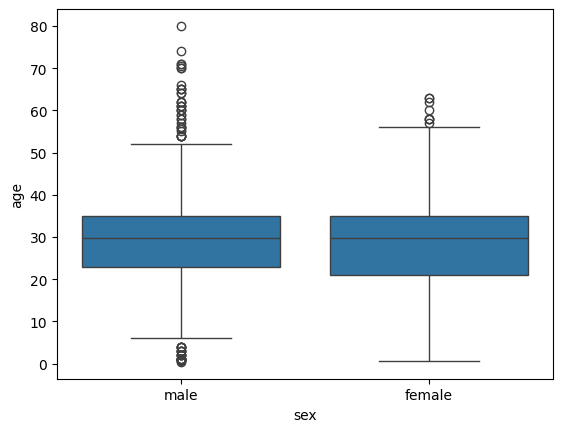

In [10]:
import seaborn as sns
sns.boxplot(data= df, y='age', x='sex')

##### 2. IQR(Inter Quartile Range) methods :

In [11]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['age'] > lower_bound) & (df['age'] < upper_bound)]

In [12]:
df.shape

(825, 14)

#### Day :35 
##### Finding and dropping Duplicate 

1. Finding 

In [13]:
df.duplicated().sum()

np.int64(109)

In [14]:
df_duplicates = df[df.duplicated()]
df_duplicates.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
47,1,3,female,29.699118,0,0,7.7500,Q,Third,woman,False,Queenstown,yes,True
76,0,3,male,29.699118,0,0,7.8958,S,Third,man,True,Southampton,no,True
77,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
87,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
95,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True


2. Dropping :

In [15]:
df.drop_duplicates(inplace=True)    

In [16]:
df.shape 

(716, 14)

##### Data Normalization : 

In [17]:
# step : 1. Libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


In [18]:
# step : 2. DAta
df


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.000000,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [19]:
# step : 3.select columns to normalize
cols_to_normalize =['age','fare']

In [20]:
# step : 4.create the scaler function
scaler = MinMaxScaler()
# when you want to scale the data instead of 0-1 i.e of your desired, we c  an use feature_range parameter in the MinMaxScaler function.
#scaler = MinMaxScaler(feature_range=(0,10)) 

In [21]:
# step : 5.fit and transform the data and vice versa
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

In [22]:
#step : 6. Check the data 
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,0.372549,1,0,0.014151,S,Third,man,True,Southampton,no,False
1,1,1,female,0.686275,1,0,0.139136,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,0.450980,0,0,0.015469,S,Third,woman,False,Southampton,yes,True
3,1,1,female,0.627451,1,0,0.103644,S,First,woman,False,Southampton,yes,False
4,0,3,male,0.627451,0,0,0.015713,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,0.705882,0,5,0.056848,Q,Third,woman,False,Queenstown,no,False
887,1,1,female,0.313725,0,0,0.058556,S,First,woman,False,Southampton,yes,True
888,0,3,female,0.523512,1,2,0.045771,S,Third,woman,False,Southampton,no,False
889,1,1,male,0.450980,0,0,0.058556,C,First,man,True,Cherbourg,yes,True


In [23]:
df.describe() # data is now in a scale of 0-1 
# min 0 and max 1, Scaling/transforming done 

,survived,pclass,age,sibsp,parch,fare
count,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000
mean,0.412011,2.277933,0.507194,0.509777,0.393855,0.066769
std,0.492541,0.845962,0.211678,0.961447,0.833673,0.102962
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.372549,0.000000,0.000000,0.015469
50%,0.000000,3.000000,0.523512,0.000000,0.000000,0.030254
75%,1.000000,3.000000,0.627451,1.000000,0.000000,0.061807
max,1.000000,3.000000,1.000000,8.000000,6.000000,1.000000


##### We can do the same thing for scaling using StandardScaler

In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# step : 2. DAta
df

# step : 3.select columns to normalize
cols_to_normalize =['age','fare']

# step : 4.create the scaler function
scaler = StandardScaler()

# step : 5.fit and transform the data and vice versa
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

# step : 6. Check the data 
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,-0.636531,1,0,-0.511396,S,Third,man,True,Southampton,no,False
1,1,1,female,0.846595,1,0,0.703347,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,-0.265749,0,0,-0.498591,S,Third,woman,False,Southampton,yes,True
3,1,1,female,0.568509,1,0,0.358401,S,First,woman,False,Southampton,yes,False
4,0,3,male,0.568509,0,0,-0.496220,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,0.939290,0,5,-0.096417,Q,Third,woman,False,Queenstown,no,False
887,1,1,female,-0.914617,0,0,-0.079818,S,First,woman,False,Southampton,yes,True
888,0,3,female,0.077142,1,2,-0.204074,S,Third,woman,False,Southampton,no,False
889,1,1,male,-0.265749,0,0,-0.079818,C,First,man,True,Cherbourg,yes,True


In [25]:
df.describe() #data is now in a scale of 0-1

,survived,pclass,age,sibsp,parch,fare
count,716.000000,716.000000,7.160000e+02,716.000000,716.000000,7.160000e+02
mean,0.412011,2.277933,3.572561e-16,0.509777,0.393855,7.318789e-17
std,0.492541,0.845962,1.000699e+00,0.961447,0.833673,1.000699e+00
min,0.000000,1.000000,-2.397743e+00,0.000000,0.000000,-6.489325e-01
25%,0.000000,1.000000,-6.365308e-01,0.000000,0.000000,-4.985913e-01
50%,0.000000,3.000000,7.714171e-02,0.000000,0.000000,-3.548898e-01
75%,1.000000,3.000000,5.685090e-01,1.000000,0.000000,-4.821997e-02
max,1.000000,3.000000,2.329721e+00,8.000000,6.000000,9.070205e+00


x_stand = (x - mean(x))/ std(x)

x_stand is the standarized variable/
x is the original value
mean(x) is the mean of variable x
std(x) is the standard deviation of variable x.

#### Day_03 :


##### Log transformation

In [31]:
boat = sns.load_dataset('titanic')
boat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [32]:
boat.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [33]:
import numpy as np

boat['age'] = boat ['age'].fillna(boat['age'].median())
boat['fare'] = boat ['fare'].fillna(boat['fare'].median())

# Log Transform
boat['age'] = np.log(boat['age'])
boat['fare'] = np.log(boat['fare'])


c:\Users\Muhammad Maaz\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [34]:
boat.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,3.091042,1,0,1.981001,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,3.637586,1,0,4.266662,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,3.258097,0,0,2.070022,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,3.555348,1,0,3.972177,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,3.555348,0,0,2.085672,S,Third,man,True,NaN,Southampton,no,True


##### After Taking the log, values becomes on a smaller Scale 
and it's an automatic range of data (not like 0-1, 0-10 etc)

<Axes: xlabel='sex', ylabel='fare'>

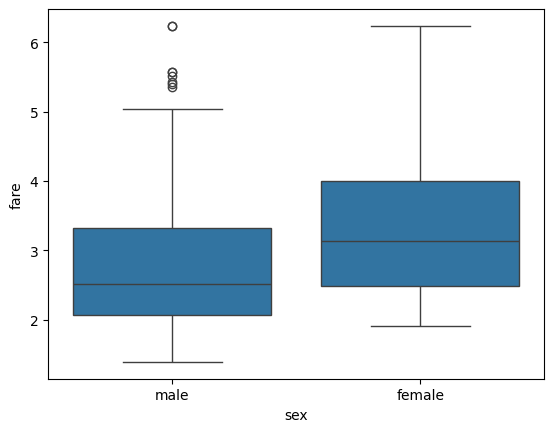

In [35]:
sns.boxplot( data= boat, x='sex', y='fare')


<Axes: xlabel='age', ylabel='Count'>

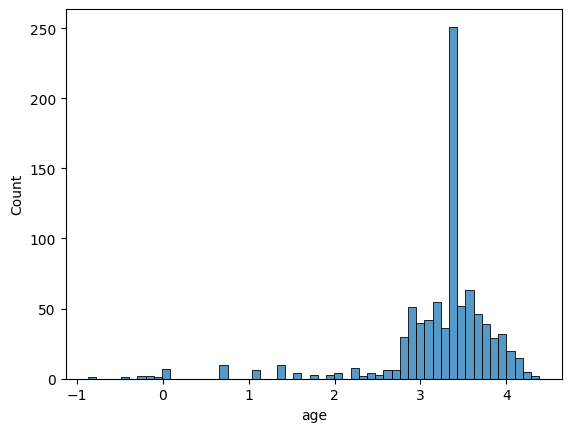

In [36]:
sns.histplot(boat['age']) 

In [37]:
boat.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

### organizing the Data :

In [38]:
df['family_size'] = df['sibsp'] + df['parch']

c:\Users\Muhammad Maaz\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='sex', ylabel='age'>

c:\Users\Muhammad Maaz\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Muhammad Maaz\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


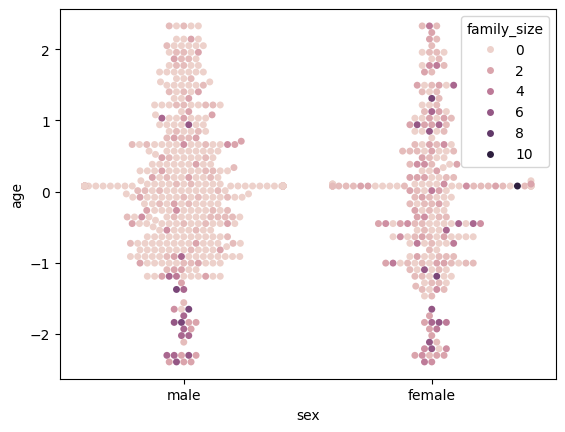

In [39]:
sns.swarmplot(data=df, x='sex', y='age', hue='family_size')

In [40]:
df = df.rename(columns={'survived' : 'survival'})

In [41]:
# pivot Table
table = pd.pivot_table ( df, values='fare', index='who',
   columns='survival', aggfunc=np.mean)
table

C:\Users\Muhammad Maaz\AppData\Local\Temp\ipykernel_25280\3912148912.py:2: FutureWarning: The provided callable <function mean at 0x000002B37D0C2820> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  table = pd.pivot_table ( df, values='fare', index='who',


survival,0,1
who,,
child,-0.108741,0.000026
man,-0.214427,0.151877
woman,-0.277348,0.439466


<Axes: xlabel='fare', ylabel='age'>

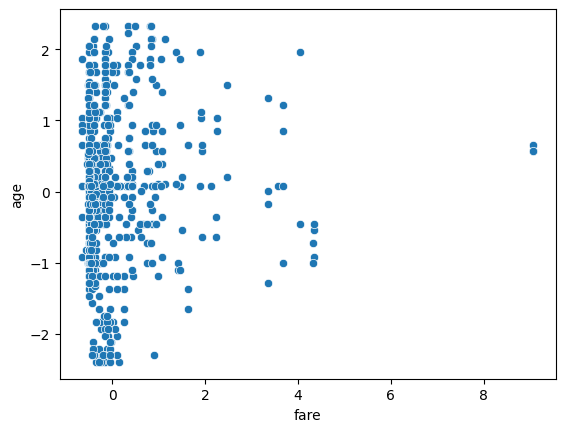

In [42]:
sns.scatterplot(df, x='fare', y='age')

In [43]:
boat.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,3.091042,1,0,1.981001,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,3.637586,1,0,4.266662,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,3.258097,0,0,2.070022,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,3.555348,1,0,3.972177,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,3.555348,0,0,2.085672,S,Third,man,True,NaN,Southampton,no,True


####  Saving the wrangled Data :

In [44]:
df.to_csv('preprocessed_data.csv') # saved the data for further 
# and after Feature Engineering the data is ready for training (Machine Learning)

#### After This we Have ML 
##### Three Main and important Libraries are :
##### 1. Scikit-learn
##### 2. pytorch
#####  3. TensorFlow 